In [1]:
!pip install -q "datasets<3.0.0" "numpy<2.0" "pandas<3.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 14.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatib

In [1]:
from datasets import load_dataset
import json

ds = load_dataset(
    "togethercomputer/RedPajama-Data-V2",
    name="default",
    partition="head_middle",
    snapshots=["2023-06"],
    languages=["en"],
    streaming=True,
    trust_remote_code=True
)

def fails_quality_filter(doc):
    qs = json.loads(doc["quality_signals"])
    word_count = qs["rps_doc_word_count"][0][2]
    if word_count < 50 or word_count > 100_000:
        return True
    mean_word_length = qs["rps_doc_mean_word_length"][0][2]
    if mean_word_length < 3 or mean_word_length > 10:
        return True
    symbol_ratio = qs["rps_doc_symbol_to_word_ratio"][0][2]
    if symbol_ratio > 0.1:
        return True
    stop_word_fraction = qs["rps_doc_stop_word_fraction"][0][2]
    if stop_word_fraction < 0.1:
        return True
    top_2gram = qs["rps_doc_frac_chars_top_2gram"][0][2]
    if top_2gram > 0.2:
        return True
    return False

dataset = []
for doc in ds["train"]:
    if not fails_quality_filter(doc):
        dataset.append(doc)
    if len(dataset) == 5000:
        break

print(f"High-quality documents collected: {len(dataset)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


High-quality documents collected: 5000


# STEP 7 - GPT2 Perplexity Scoring

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Computing GPT-2 perplexity for 5000 documents...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Processed 500/5000...
  Processed 1000/5000...
  Processed 1500/5000...
  Processed 2000/5000...
  Processed 2500/5000...
  Processed 3000/5000...
  Processed 3500/5000...
  Processed 4000/5000...
  Processed 4500/5000...
  Processed 5000/5000...

Successfully scored: 5000 documents
Failed/exploded:     0 documents

GPT-2 Perplexity Stats:
  Average: 28.3
  Median:  26.2
  Min:      2.3
  Max:      235.2

--- Detailed GPT-2 Perplexity Breakdown ---
Repetitive/Bot (<50)     :  4733 docs (94.7%)
High Quality (50-100)    :   251 docs (5.0%)
Good Web (100-150)       :    15 docs (0.3%)
Informal (150-200)       :     0 docs (0.0%)
Noisy Web (200-300)      :     1 docs (0.0%)
Low Quality (300+)       :     0 docs (0.0%)


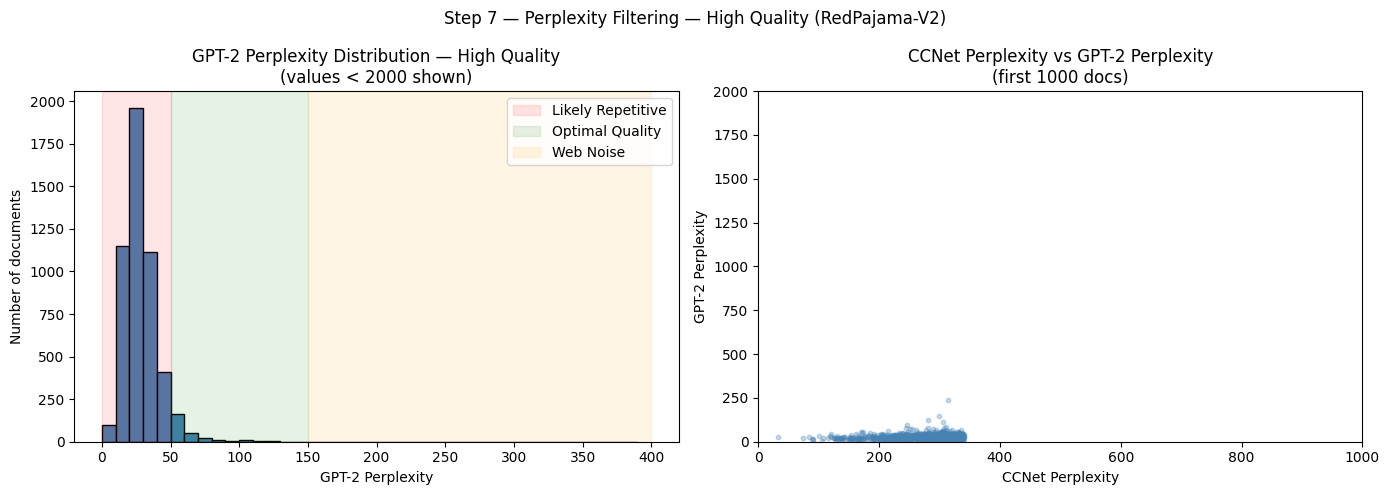


--- 3 Documents in 'Repetitive/Bot' category (GPT-2 perplexity < 50) ---

GPT-2 Perplexity: 31.5
Content: Ohmydollz Frogitaire Jurassic Pinball Kore Putt Sling Jumper 2
Franckfort
California To Enforce Stringent Auto Emission Regulations
Earlier, the state of California issued proposed emissions regulatio

GPT-2 Perplexity: 23.4
Content: What our clients say about our service.
Thanks for the great Job! (L.C.)
TI loved working with Bud and Norman. They were so thorough and explained everything so well, both verbally and in the written 

GPT-2 Perplexity: 24.6
Content: Updaty posty thingy
Sooo....
Chainmaille was a disaster. I need someone to show me how to construct. It was moot anyway, as I had an anxiety attack and barely made it in to the con. I am so embarased,

--- 3 Documents in 'Low Quality' category (GPT-2 perplexity > 300) ---


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model.eval()

def compute_gpt2_perplexity(text, max_length=512):
    encodings = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )
    input_ids = encodings.input_ids.to(device)

    if input_ids.shape[1] < 2:
        return None

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss

    return torch.exp(loss).item()

gpt2_perplexities = []
failed = 0

print("Computing GPT-2 perplexity for 5000 documents...")
for i, doc in enumerate(dataset):
    ppl = compute_gpt2_perplexity(doc["raw_content"])
    if ppl is not None and ppl < 100000:
        gpt2_perplexities.append((i, ppl))
    else:
        failed += 1
    if (i + 1) % 500 == 0:
        print(f"  Processed {i+1}/5000...")

valid_ppls = [ppl for _, ppl in gpt2_perplexities]
print(f"\nSuccessfully scored: {len(valid_ppls)} documents")
print(f"Failed/exploded:     {failed} documents")
print(f"\nGPT-2 Perplexity Stats:")
print(f"  Average: {np.mean(valid_ppls):.1f}")
print(f"  Median:  {np.median(valid_ppls):.1f}")
print(f"  Min:      {min(valid_ppls):.1f}")
print(f"  Max:      {max(valid_ppls):.1f}")

bins = [0, 50, 100, 150, 200, 300, 500]
labels = ['Repetitive/Bot (<50)', 'High Quality (50-100)', 'Good Web (100-150)', 'Informal (150-200)', 'Noisy Web (200-300)', 'Low Quality (300+)']

p_series = pd.Series(valid_ppls)
categories = pd.cut(p_series, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

print("\n--- Detailed GPT-2 Perplexity Breakdown ---")
for label, count in counts.items():
    percentage = (count / len(valid_ppls)) * 100
    print(f"{label:25}: {count:5} docs ({percentage:.1f}%)")

ccnet_ppls = [json.loads(dataset[i]["quality_signals"])["ccnet_perplexity"][0][2] for i, _ in gpt2_perplexities]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist([p for p in valid_ppls if p < 2000], bins=range(0, 400, 10), color="steelblue", edgecolor="black")
axes[0].axvspan(0, 50, color='red', alpha=0.1, label='Likely Repetitive')
axes[0].axvspan(50, 150, color='green', alpha=0.1, label='Optimal Quality')
axes[0].axvspan(150, 400, color='orange', alpha=0.1, label='Web Noise')
axes[0].set_title("GPT-2 Perplexity Distribution \u2014 High Quality\n(values < 2000 shown)")
axes[0].set_xlabel("GPT-2 Perplexity")
axes[0].set_ylabel("Number of documents")
axes[0].legend()

axes[1].scatter(ccnet_ppls[:1000], valid_ppls[:1000], alpha=0.3, color="steelblue", s=10)
axes[1].set_title("CCNet Perplexity vs GPT-2 Perplexity\n(first 1000 docs)")
axes[1].set_xlabel("CCNet Perplexity")
axes[1].set_ylabel("GPT-2 Perplexity")
axes[1].set_xlim(0, 1000)
axes[1].set_ylim(0, 2000)

plt.suptitle("Step 7 \u2014 Perplexity Filtering \u2014 High Quality (RedPajama-V2)")
plt.tight_layout()
plt.show()

print("\n--- 3 Documents in 'Repetitive/Bot' category (GPT-2 perplexity < 50) ---")
low_ppl_docs = [(i, ppl) for i, ppl in gpt2_perplexities if ppl < 50][:3]
for idx, ppl in low_ppl_docs:
    print(f"\nGPT-2 Perplexity: {ppl:.1f}")
    print(f"Content: {dataset[idx]['raw_content'][:200]}")

print("\n--- 3 Documents in 'Low Quality' category (GPT-2 perplexity > 300) ---")
high_ppl_docs = [(i, ppl) for i, ppl in gpt2_perplexities if ppl > 300][:3]
for idx, ppl in high_ppl_docs:
    print(f"\nGPT-2 Perplexity: {ppl:.1f}")
    print(f"Content: {dataset[idx]['raw_content'][:200]}")

# STEP 8 - Fine-tuning GPT-2

In [4]:
import os
import shutil
from transformers import GPT2LMHeadModel, GPT2Tokenizer, DataCollatorForLanguageModeling, Trainer, TrainingArguments
from torch.utils.data import Dataset
import random
import torch

output_dir = "./gpt2-high-quality"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

random.seed(14)
finetune_sample = random.sample(dataset, 3500)
texts = [doc["raw_content"] for doc in finetune_sample]

print(f"Fine-tuning on {len(texts)} high-quality documents")

with open("high_quality_train.txt", "w", encoding="utf-8") as f:
    for text in texts:
        f.write(text.strip().replace("\n", " ") + "\n")

class TextFileDataset(Dataset):
    def __init__(self, file_path, tokenizer, block_size=128):
        with open(file_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if len(line.strip()) > 10]

        self.examples = []
        for line in lines:
            encodings = tokenizer(
                line,
                truncation=True,
                max_length=block_size,
                padding="max_length",
                return_tensors="pt"
            )
            self.examples.append(encodings.input_ids.squeeze())

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return {"input_ids": self.examples[idx], "labels": self.examples[idx]}

ft_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
ft_tokenizer.pad_token = ft_tokenizer.eos_token
ft_model = GPT2LMHeadModel.from_pretrained("gpt2")

train_dataset = TextFileDataset("high_quality_train.txt", ft_tokenizer, block_size=128)
print(f"Training examples: {len(train_dataset)}")

training_args = TrainingArguments(
    output_dir="./gpt2-high-quality",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    save_steps=500,
    logging_steps=100,
    prediction_loss_only=True,
    report_to="none"
)
data_collator = DataCollatorForLanguageModeling(
    tokenizer=ft_tokenizer,
    mlm=False  # GPT-2 is Causal LM, not Masked LM
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset,
)

print("Starting fine-tuning on high-quality data...")
trainer.train()
print("Fine-tuning complete.")

ft_model.save_pretrained("./gpt2-high-quality-final")
ft_tokenizer.save_pretrained("./gpt2-high-quality-final")
print("Model saved successfully.")


Fine-tuning on 3500 high-quality documents


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training examples: 3500
Starting fine-tuning on high-quality data...


Step,Training Loss
100,3.583033
200,3.516320
300,3.343174
400,3.333786
500,3.251285
600,3.201656


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning complete.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


## GENERATE TEXT FROM FINE-TUNED MODEL

In [5]:
from transformers import pipeline

generator_hq = pipeline(
    "text-generation",
    model="./gpt2-high-quality-final",
    tokenizer="./gpt2-high-quality-final",
    device=0 if torch.cuda.is_available() else -1
)

prompts = [
    "The researchers found that",
    "In recent years, artificial intelligence has",
    "The study concluded that data quality"
]

print("=" * 60)
print("TEXT GENERATION — HIGH QUALITY FINE-TUNED GPT-2")
print("=" * 60)

for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")
    print("-" * 40)
    outputs = generator_hq(
        prompt,
        max_length=100,
        num_return_sequences=2,
        temperature=0.9,
        do_sample=True,
        pad_token_id=ft_tokenizer.eos_token_id
    )
    for i, output in enumerate(outputs):
        print(f"Generation {i+1}: {output['generated_text']}")
    print()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_length', 'num_return_sequences', 'pad_token_id', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TEXT GENERATION — HIGH QUALITY FINE-TUNED GPT-2

Prompt: 'The researchers found that'
----------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generation 1: The researchers found that, based on the results, you could predict the severity of pain you might experience by tracking blood flow to your extremities and brain. The more likely the blood is to flow to the brain, the greater your likelihood of experiencing pain. When a new injury occurs, researchers use this information to try to predict the severity of the pain, and then compare it to the pain of your regular pain.

In other words, if you have sore feet, you might feel more pain than your normal feet, but you should still take extra precautions. You should also exercise more frequently, and be more comfortable with taking your daily dose of steroids, like Tylenol.
Generation 2: The researchers found that the protein is expressed in brain cells of adult monkeys. The scientists found that the protein is expressed in brain cells of adult monkeys. The researchers found that the protein is expressed in brain cells of adult monkeys. Photo: AP Photo/Shutterstock The researche

Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generation 1: In recent years, artificial intelligence has been increasingly being used to enhance our sense of touch, communicate with people, and connect with new people, often with little or no knowledge of our past. By 2020, AI was expected to become the norm, and a new era of automation has been born. The following is a brief summary of the various benefits AI is expected to bring to our daily lives. It might seem that AI has a lot in common with the joys of human interaction, but the joys of human interaction tend to vary depending on the context in which the interaction takes place. This is due to the way each user interacts with their environment—their own actions, emotions, and desires interact with each other, as well as their own personality types (mental capacities, attitudes, and behavior). The human brain does not make these choices for its own purposes; it makes these for its own needs. The benefits of AI may vary based on your background, and you may decide that the AI 

# STEP 9 - Summary Visualizations

QUALITY SIGNAL SUMMARY — HIGH QUALITY DATASET
Metric                                  Mean   Median
-------------------------------------------------------
CCNet Perplexity                       270.0    281.7
GPT-2 Perplexity                        28.3     26.2
Stop-word fraction                     0.371    0.380
Mean word length                       4.956    4.914
Non-alphabetical fraction              0.172    0.159
Unigram entropy                        4.962    5.019
Word count                             915.5    499.0
PALM score                            0.3496   0.2419


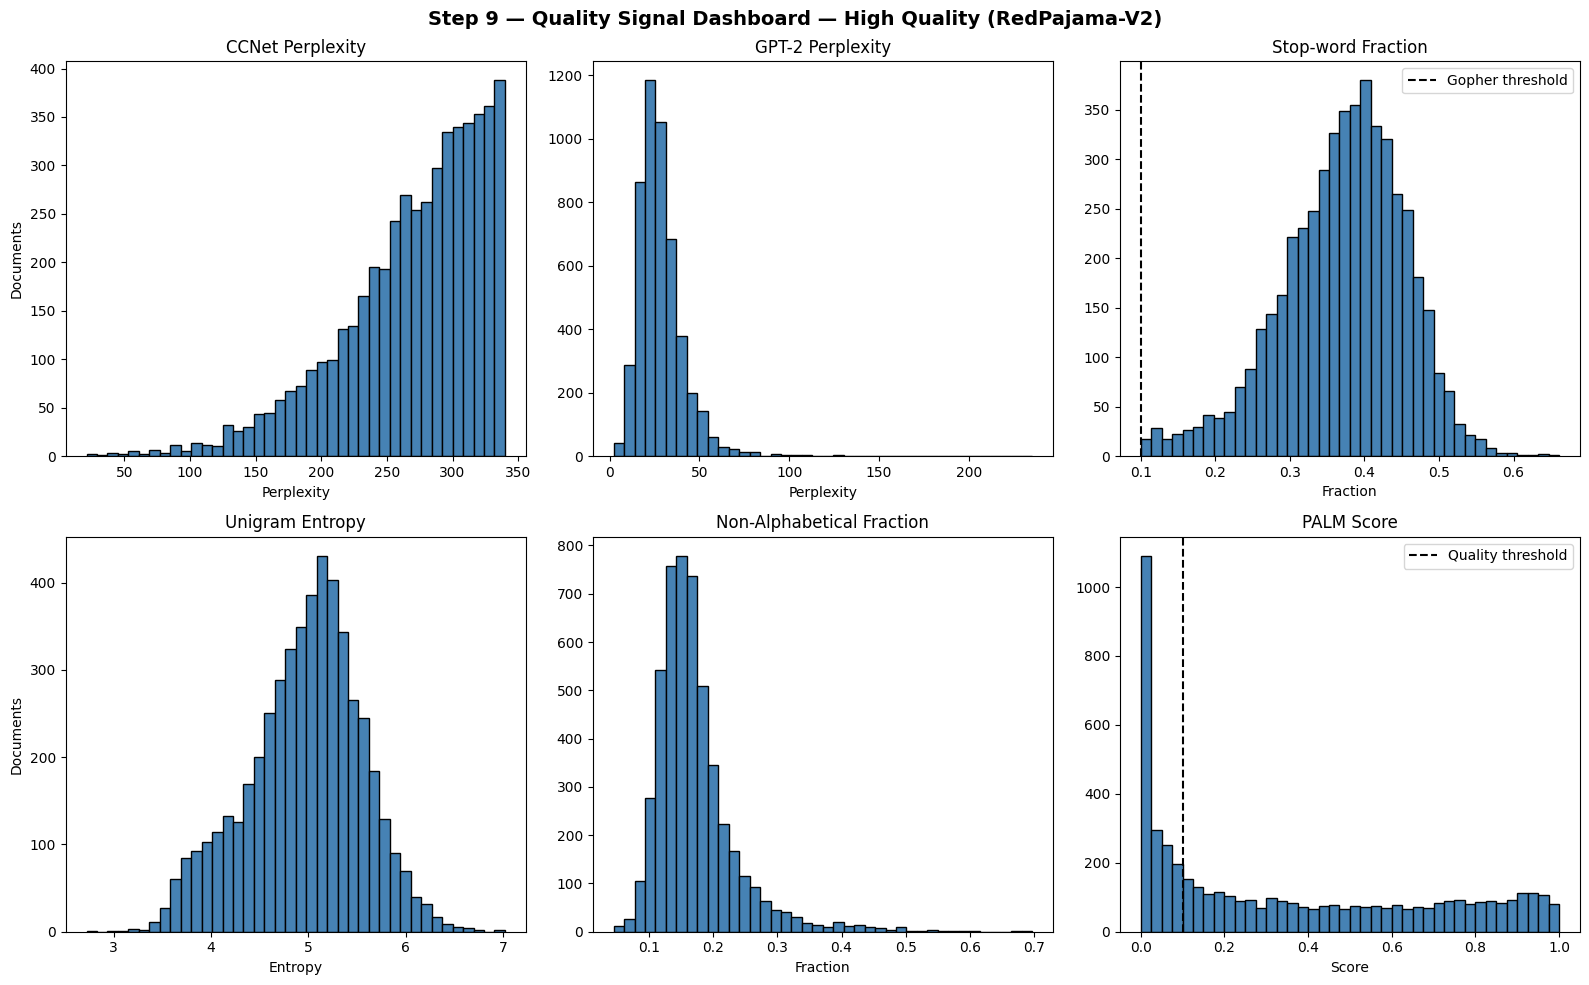

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

stop_word_fractions = []
mean_word_lengths   = []
no_alph_fractions  = []
unigram_entropies  = []
word_counts        = []
ccnet_perplexities = []
palm_scores        = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    stop_word_fractions.append(qs["rps_doc_stop_word_fraction"][0][2])
    mean_word_lengths.append(qs["rps_doc_mean_word_length"][0][2])
    no_alph_fractions.append(qs["rps_doc_frac_no_alph_words"][0][2])
    unigram_entropies.append(qs["rps_doc_unigram_entropy"][0][2])
    word_counts.append(qs["rps_doc_word_count"][0][2])
    ccnet_perplexities.append(qs["ccnet_perplexity"][0][2])
    palm = qs["rps_doc_ml_palm_score"][0][2]
    if palm is not None:
        palm_scores.append(palm)

print("=" * 55)
print("QUALITY SIGNAL SUMMARY — HIGH QUALITY DATASET")
print("=" * 55)
print(f"{'Metric':<35} {'Mean':>8} {'Median':>8}")
print("-" * 55)
print(f"{'CCNet Perplexity':<35} {np.mean(ccnet_perplexities):>8.1f} {np.median(ccnet_perplexities):>8.1f}")
print(f"{'GPT-2 Perplexity':<35} {np.mean(valid_ppls):>8.1f} {np.median(valid_ppls):>8.1f}")
print(f"{'Stop-word fraction':<35} {np.mean(stop_word_fractions):>8.3f} {np.median(stop_word_fractions):>8.3f}")
print(f"{'Mean word length':<35} {np.mean(mean_word_lengths):>8.3f} {np.median(mean_word_lengths):>8.3f}")
print(f"{'Non-alphabetical fraction':<35} {np.mean(no_alph_fractions):>8.3f} {np.median(no_alph_fractions):>8.3f}")
print(f"{'Unigram entropy':<35} {np.mean(unigram_entropies):>8.3f} {np.median(unigram_entropies):>8.3f}")
print(f"{'Word count':<35} {np.mean(word_counts):>8.1f} {np.median(word_counts):>8.1f}")
print(f"{'PALM score':<35} {np.mean(palm_scores):>8.4f} {np.median(palm_scores):>8.4f}")
print("=" * 55)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0][0].hist([p for p in ccnet_perplexities if p < 1000], bins=40, color="steelblue", edgecolor="black")
axes[0][0].set_title("CCNet Perplexity")
axes[0][0].set_xlabel("Perplexity")
axes[0][0].set_ylabel("Documents")

axes[0][1].hist([p for p in valid_ppls if p < 2000], bins=40, color="steelblue", edgecolor="black")
axes[0][1].set_title("GPT-2 Perplexity")
axes[0][1].set_xlabel("Perplexity")

axes[0][2].hist(stop_word_fractions, bins=40, color="steelblue", edgecolor="black")
axes[0][2].axvline(0.1, color="black", linestyle="--", label="Gopher threshold")
axes[0][2].set_title("Stop-word Fraction")
axes[0][2].set_xlabel("Fraction")
axes[0][2].legend()

axes[1][0].hist(unigram_entropies, bins=40, color="steelblue", edgecolor="black")
axes[1][0].set_title("Unigram Entropy")
axes[1][0].set_xlabel("Entropy")
axes[1][0].set_ylabel("Documents")

axes[1][1].hist(no_alph_fractions, bins=40, color="steelblue", edgecolor="black")
axes[1][1].set_title("Non-Alphabetical Fraction")
axes[1][1].set_xlabel("Fraction")

axes[1][2].hist(palm_scores, bins=40, color="steelblue", edgecolor="black")
axes[1][2].axvline(0.1, color="black", linestyle="--", label="Quality threshold")
axes[1][2].set_title("PALM Score")
axes[1][2].set_xlabel("Score")
axes[1][2].legend()

plt.suptitle("Step 9 — Quality Signal Dashboard — High Quality (RedPajama-V2)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
